# A/B-тест нового алгоритма рекомендаций

Проект по планированию и анализу A/B-эксперимента для развлекательного приложения с бесконечной лентой.

**Цель:** проверить, увеличивает ли новый алгоритм рекомендаций долю успешных первых сессий — сессий, в которых пользователь просмотрел **4 и более страниц**.

В проекте:
- проведён исследовательский анализ исторических данных;
- рассчитаны размер выборки и ожидаемая длительность эксперимента;
- проверена корректность разделения пользователей на группы;
- проанализирована ключевая метрика;
- выполнен односторонний z-тест для двух долей;
- сформулирован продуктовый вывод по результатам эксперимента.


## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from math import ceil

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest
)

sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
user_sessions = (
    sessions_history
    .groupby('user_id')['session_id']
    .nunique()
    .sort_values(ascending=False)
)

display(user_sessions.head())

max_user = user_sessions.idxmax()
max_sessions = user_sessions.max()

print('Пользователь:', max_user)
print('Количество сессий:', max_sessions)

display(
    sessions_history[
        sessions_history['user_id'] == max_user
    ].sort_values('session_number')
)

user_id
10E0DEFC1ABDBBE0    10
6A73CB5566BB494D    10
8A60431A825D035B     9
D11541BAC141FB94     9
5BCFE7C4DCC148E9     9
Name: session_id, dtype: int64

Пользователь: 10E0DEFC1ABDBBE0
Количество сессий: 10


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [3]:
daily_stats = (
    sessions_history
    .groupby('session_date')
    .agg(
        total_users=('user_id', 'nunique'),
        registered_users=('registration_flag', 'sum')
    )
    .reset_index()
)

daily_stats['registered_share'] = (
    daily_stats['registered_users']
    / daily_stats['total_users']
)

display(daily_stats.head())

,session_date,total_users,registered_users,registered_share
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


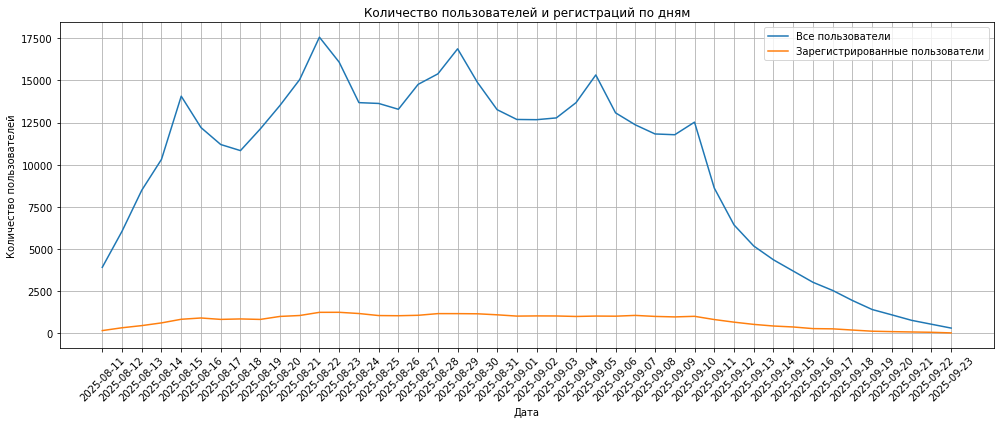

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_stats['session_date'],
    daily_stats['total_users'],
    label='Все пользователи'
)

plt.plot(
    daily_stats['session_date'],
    daily_stats['registered_users'],
    label='Зарегистрированные пользователи'
)

plt.title('Количество пользователей и регистраций по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

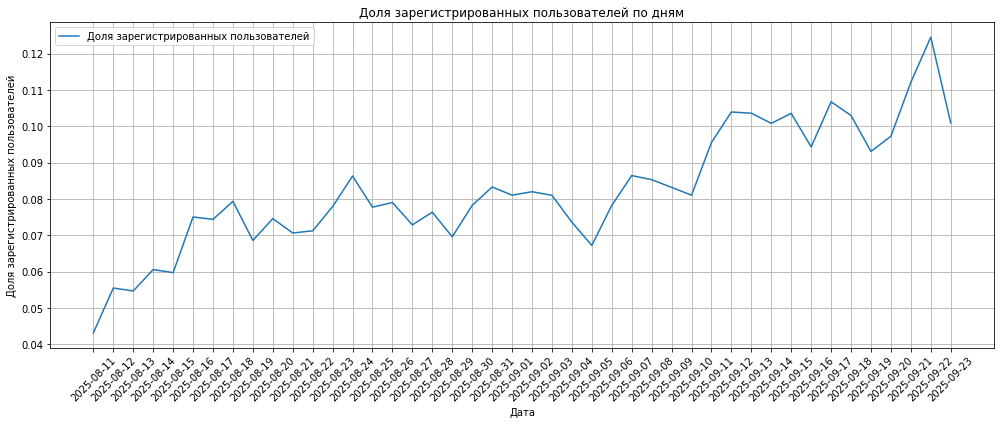

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_stats['session_date'],
    daily_stats['registered_share'],
    label='Доля зарегистрированных пользователей'
)

plt.title('Доля зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Количество активных и зарегистрированных пользователей изменяется во времени. Для более корректной оценки динамики дополнительно была рассчитана доля зарегистрированных пользователей от общего количества активных пользователей. Это позволяет оценивать регистрацию независимо от изменения общего дневного трафика.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

In [6]:
first_sessions = sessions_history[
    sessions_history['session_number'] == 1
].copy()

pages_distribution = (
    first_sessions['page_counter']
    .value_counts()
    .sort_index()
)

display(pages_distribution)

1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: page_counter, dtype: int64

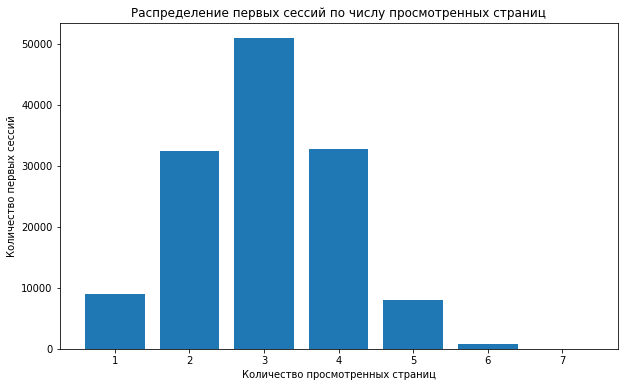

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(
    pages_distribution.index,
    pages_distribution.values
)

plt.title('Распределение первых сессий по числу просмотренных страниц')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество первых сессий')

plt.show()

Распределение показывает, сколько первых сессий приходится на каждое количество просмотренных страниц. Именно первые сессии особенно важны для оценки качества рекомендаций, поскольку отражают первое взаимодействие пользователя с контентом приложения.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

In [8]:
sessions_history['good_session'] = (
    sessions_history['page_counter'] >= 4
).astype(int)

In [9]:
first_sessions = sessions_history[
    sessions_history['session_number'] == 1
].copy()

In [10]:
daily_good_sessions = (
    first_sessions
    .groupby('session_date')['good_session']
    .mean()
    .reset_index()
)

display(daily_good_sessions.head())

,session_date,good_session
0,2025-08-11,0.312835
1,2025-08-12,0.298344
2,2025-08-13,0.306861
3,2025-08-14,0.319098
4,2025-08-15,0.311114


In [11]:
history_success_rate = first_sessions['good_session'].mean()

print(
    f'Средняя доля успешных первых сессий: '
    f'{history_success_rate:.2%}'
)

Средняя доля успешных первых сессий: 31.06%


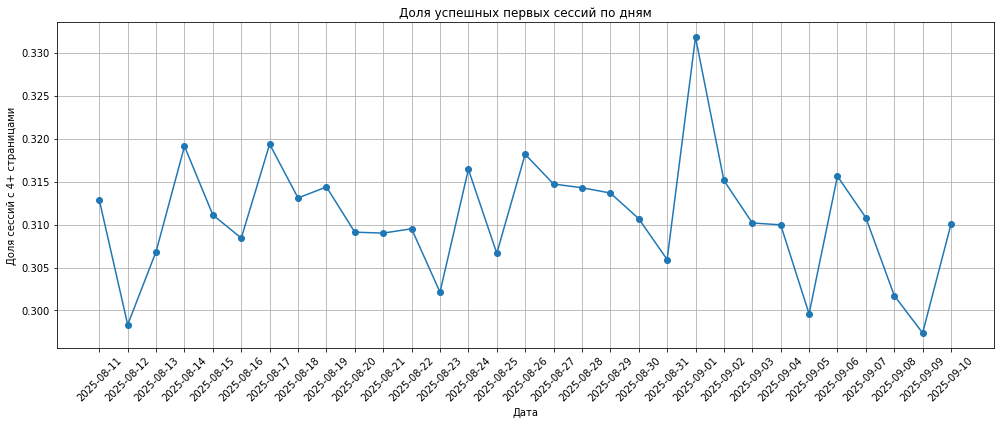

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_good_sessions['session_date'],
    daily_good_sessions['good_session'],
    marker='o'
)

plt.title('Доля успешных первых сессий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля сессий с 4+ страницами')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [13]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2    # Ошибка второго рода
power = 1 - beta  # Мощность теста
p = 0.3       # Базовый уровень доли
mde = 0.03    # Минимальный детектируемый эффект

effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [14]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (
    sessions_history
    .groupby('session_date')['user_id']
    .nunique()
    .mean()
)

# Рассчитываем длительность теста
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(
    f"Рассчитанная длительность A/B-теста при текущем уровне трафика "
    f"в {avg_daily_users} пользователей в день составит {test_duration} дней"
)

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

sessions_test_part = pd.read_csv(
    'https://code.s3.yandex.net/datasets/sessions_project_test_part.csv'
)

sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


In [16]:
sessions_test_part['session_date'].unique()

array(['2025-10-14'], dtype=object)

In [17]:
group_users = (
    sessions_test_part
    .groupby('test_group')['user_id']
    .nunique()
)

print(group_users)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


In [18]:
users_a = group_users['A']
users_b = group_users['B']

percent_difference = (
    100 * abs(users_a - users_b) / users_a
)

print(f'Количество пользователей в группе A: {users_a}')
print(f'Количество пользователей в группе B: {users_b}')
print(f'Процентная разница: {percent_difference:.2f}%')

Количество пользователей в группе A: 1477
Количество пользователей в группе B: 1466
Процентная разница: 0.74%


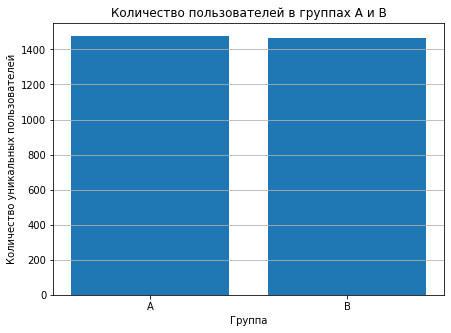

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(
    group_users.index,
    group_users.values
)

plt.title('Количество пользователей в группах A и B')
plt.xlabel('Группа')
plt.ylabel('Количество уникальных пользователей')
plt.grid(axis='y')

plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [20]:
users_a = set(
    sessions_test_part.loc[
        sessions_test_part['test_group'] == 'A',
        'user_id'
    ]
)

users_b = set(
    sessions_test_part.loc[
        sessions_test_part['test_group'] == 'B',
        'user_id'
    ]
)

In [21]:
users_intersection = users_a.intersection(users_b)

print(
    f'Количество пользователей, попавших в обе группы: '
    f'{len(users_intersection)}'
)

Количество пользователей, попавших в обе группы: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [22]:
users_devices = (
    sessions_test_part[
        ['user_id', 'test_group', 'device']
    ]
    .drop_duplicates()
)

In [23]:
device_distribution = (
    users_devices
    .groupby('test_group')['device']
    .value_counts(normalize=True)
    .rename('share')
    .reset_index()
)

device_distribution

,test_group,device,share
0,A,Android,0.444144
1,A,PC,0.249831
2,A,iPhone,0.200406
3,A,Mac,0.105619
4,B,Android,0.455662
5,B,PC,0.259891
6,B,iPhone,0.183492
7,B,Mac,0.100955


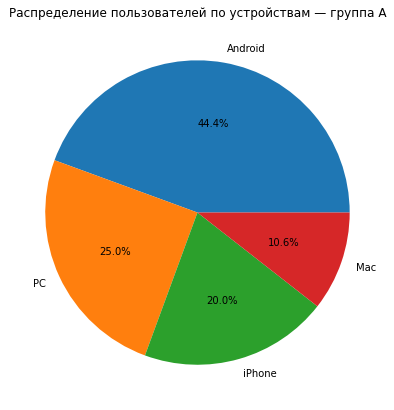

In [24]:
device_a = device_distribution[
    device_distribution['test_group'] == 'A'
]

plt.figure(figsize=(7, 7))

plt.pie(
    device_a['share'],
    labels=device_a['device'],
    autopct='%1.1f%%',
    normalize=True
)

plt.title('Распределение пользователей по устройствам — группа A')

plt.show()

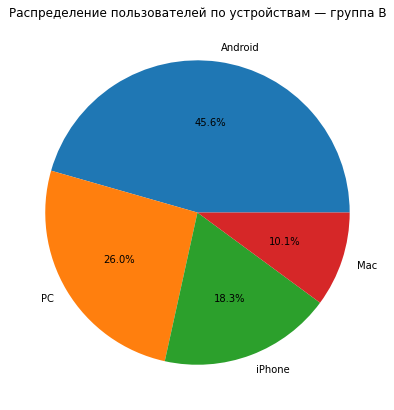

In [25]:
device_b = device_distribution[
    device_distribution['test_group'] == 'B'
]

plt.figure(figsize=(7, 7))

plt.pie(
    device_b['share'],
    labels=device_b['device'],
    autopct='%1.1f%%',
    normalize=True
)

plt.title('Распределение пользователей по устройствам — группа B')

plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [26]:
users_regions = (
    sessions_test_part[
        ['user_id', 'test_group', 'region']
    ]
    .drop_duplicates()
)

In [27]:
region_distribution = (
    users_regions
    .groupby('test_group')['region']
    .value_counts(normalize=True)
    .rename('share')
    .reset_index()
)

region_distribution

,test_group,region,share
0,A,CIS,0.436019
1,A,MENA,0.412322
2,A,EU,0.151659
3,B,CIS,0.439973
4,B,MENA,0.412005
5,B,EU,0.148022


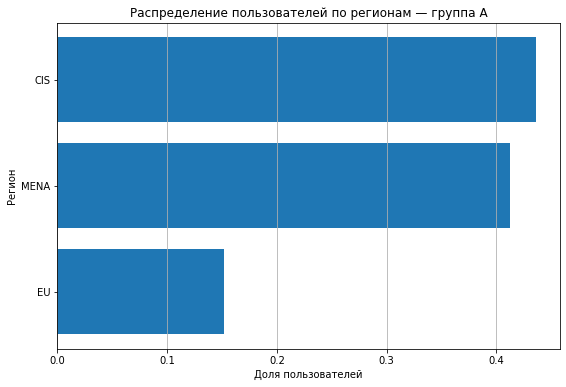

In [28]:
region_a = region_distribution[
    region_distribution['test_group'] == 'A'
].sort_values('share')

plt.figure(figsize=(9, 6))

plt.barh(
    region_a['region'],
    region_a['share']
)

plt.title('Распределение пользователей по регионам — группа A')
plt.xlabel('Доля пользователей')
plt.ylabel('Регион')
plt.grid(axis='x')

plt.show()

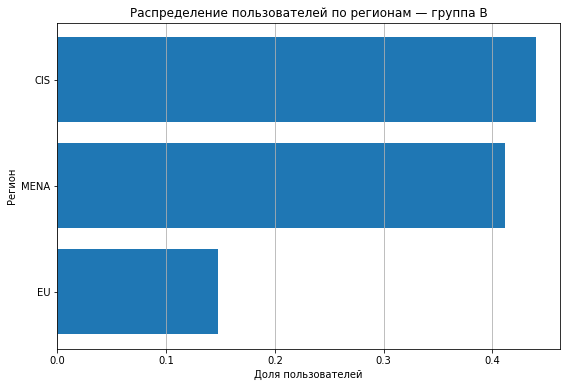

In [29]:
region_b = region_distribution[
    region_distribution['test_group'] == 'B'
].sort_values('share')

plt.figure(figsize=(9, 6))

plt.barh(
    region_b['region'],
    region_b['share']
)

plt.title('Распределение пользователей по регионам — группа B')
plt.xlabel('Доля пользователей')
plt.ylabel('Регион')
plt.grid(axis='x')

plt.show()

#### 3.5. Вывод после проверки A/B-теста

В ходе промежуточной проверки A/B-теста было проанализировано распределение пользователей между группами A и B.

Количество пользователей в группах отличается незначительно, поэтому существенного дисбаланса по размеру выборок не наблюдается.

Пользователей, одновременно попавших в группы A и B, не обнаружено. Следовательно, выборки являются независимыми.

Распределение пользователей по типам устройств в группах также близкое. В группе A доли составляют: Android — 44,4%, PC — 25,0%, iPhone — 20,0%, Mac — 10,6%. В группе B: Android — 45,6%, PC — 26,0%, iPhone — 18,3%, Mac — 10,1%. Существенных различий между группами по устройствам не наблюдается.

Распределение пользователей по регионам также практически совпадает: в обеих группах около 44% пользователей относятся к CIS, около 41% — к MENA и около 15% — к EU. Значимого перекоса по регионам не наблюдается.

Таким образом, A/B-тест проходит корректно. Группы независимы, сопоставимы по размеру и имеют похожее распределение по устройствам и регионам. Существенных нарушений в формировании экспериментальных групп не обнаружено, поэтому результаты теста можно использовать для дальнейшего анализа.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [30]:
# Загружаем данные A/B-теста
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

# Создаём признак успешной сессии
sessions_test['good_session'] = (
    sessions_test['page_counter'] >= 4
).astype(int)

sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


In [31]:
sessions_test['good_session'].value_counts()

0    68698
1    31307
Name: good_session, dtype: int64

### 4.2. Формулировка гипотез. Определение целевой, прокси- и барьерных метрик

**Целевая метрика** — доля успешных первых сессий, то есть доля первых сессий, в которых пользователь просмотрел 4 и более страниц.

Пусть (p_A) — доля успешных первых сессий в контрольной группе A, а (p_B) — доля успешных первых сессий в тестовой группе B с новым алгоритмом рекомендаций.

**Нулевая гипотеза (H_0):** новый алгоритм рекомендаций не увеличивает долю успешных первых сессий:

[
H_0: p_B \leq p_A
]

**Альтернативная гипотеза (H_1):** новый алгоритм рекомендаций увеличивает долю успешных первых сессий:

[
H_1: p_B > p_A
]

В качестве **прокси-метрик** можно использовать среднее количество просмотренных страниц за сессию, среднюю продолжительность сессии, число сессий на пользователя, возвращаемость пользователей и конверсию в регистрацию.

В качестве **барьерных метрик** можно отслеживать скорость загрузки ленты, количество технических ошибок, рекламную выручку и конверсию в платную подписку. Эти показатели не должны ухудшаться после внедрения нового алгоритма рекомендаций. 


#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [32]:
first_sessions_test = sessions_test[
    sessions_test['session_number'] == 1
].copy()

In [33]:
print(
    'Количество первых сессий:',
    len(first_sessions_test)
)

print(
    'Количество уникальных пользователей:',
    first_sessions_test['user_id'].nunique()
)

Количество первых сессий: 30578
Количество уникальных пользователей: 30578


In [34]:
success_rate = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .mean()
)

print(success_rate)

test_group
A    0.315724
B    0.314673
Name: good_session, dtype: float64


In [35]:
rate_a = success_rate['A']
rate_b = success_rate['B']

difference = rate_b - rate_a

print(f'Доля успешных первых сессий в группе A: {rate_a:.2%}')
print(f'Доля успешных первых сессий в группе B: {rate_b:.2%}')
print(f'Разница B - A: {difference:.2%}')
print(f'Разница: {difference * 100:.2f} п.п.')

Доля успешных первых сессий в группе A: 31.57%
Доля успешных первых сессий в группе B: 31.47%
Разница B - A: -0.11%
Разница: -0.11 п.п.


In [36]:
relative_difference = (rate_b / rate_a - 1) * 100

print(
    f'Относительное изменение метрики: '
    f'{relative_difference:.2f}%'
)

Относительное изменение метрики: -0.33%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [37]:
from statsmodels.stats.proportion import proportions_ztest

In [38]:
ab_stats = (
    first_sessions_test
    .groupby('test_group')['good_session']
    .agg(['sum', 'count'])
)

ab_stats

,sum,count
test_group,,
A,4787,15162
B,4851,15416


In [39]:
success_a = ab_stats.loc['A', 'sum']
success_b = ab_stats.loc['B', 'sum']

n_a = ab_stats.loc['A', 'count']
n_b = ab_stats.loc['B', 'count']

z_stat, p_value = proportions_ztest(
    count=[success_b, success_a],
    nobs=[n_b, n_a],
    alternative='larger'
)

print(f'z-statistic: {z_stat:.4f}')
print(f'p-value: {p_value:.6f}')

z-statistic: -0.1977
p-value: 0.578352


In [40]:
alpha = 0.05

if p_value < alpha:
    print(
        'p-value меньше 0.05. '
        'Нулевая гипотеза отвергается. '
        'Рост доли успешных первых сессий '
        'в группе B статистически значим.'
    )
else:
    print(
        'p-value больше или равно 0.05. '
        'Нулевая гипотеза не отвергается. '
        'Статистически значимого роста доли '
        'успешных первых сессий не обнаружено.'
    )

p-value больше или равно 0.05. Нулевая гипотеза не отвергается. Статистически значимого роста доли успешных первых сессий не обнаружено.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

In [41]:
users_by_group = (
    sessions_test
    .groupby('test_group')['user_id']
    .nunique()
)

total_users = sessions_test['user_id'].nunique()

print('Количество пользователей по группам:')
print(users_by_group)

print(
    f'\nВсего уникальных пользователей: '
    f'{total_users}'
)

Количество пользователей по группам:
test_group
A    15163
B    15416
Name: user_id, dtype: int64

Всего уникальных пользователей: 30579


In [42]:
sessions_test['session_date'] = pd.to_datetime(
    sessions_test['session_date']
)

start_date = sessions_test['session_date'].min()
end_date = sessions_test['session_date'].max()

test_days = (end_date - start_date).days + 1

print(f'Начало теста: {start_date.date()}')
print(f'Окончание теста: {end_date.date()}')
print(f'Длительность теста: {test_days} дней')

Начало теста: 2025-10-14
Окончание теста: 2025-11-02
Длительность теста: 20 дней


In [43]:
print(f'Всего пользователей: {total_users}')
print(f'Группа A: {users_by_group["A"]}')
print(f'Группа B: {users_by_group["B"]}')
print(f'Длительность эксперимента: {test_days} дней')

print(f'\nМетрика A: {rate_a:.2%}')
print(f'Метрика B: {rate_b:.2%}')
print(f'Изменение: {(rate_b - rate_a) * 100:.2f} п.п.')
print(f'Относительное изменение: {relative_difference:.2f}%')

print(f'\np-value: {p_value:.6f}')

Всего пользователей: 30579
Группа A: 15163
Группа B: 15416
Длительность эксперимента: 20 дней

Метрика A: 31.57%
Метрика B: 31.47%
Изменение: -0.11 п.п.
Относительное изменение: -0.33%

p-value: 0.578352


### 4.5. Вывод по результатам A/B-эксперимента

A/B-тест проводился с 14 октября по 2 ноября 2025 года и продолжался 20 дней. Всего в эксперименте приняли участие 30 579 уникальных пользователей: 15 163 пользователя в контрольной группе A и 15 416 пользователей в тестовой группе B.

Ключевой метрикой эксперимента была доля успешных первых сессий — доля первых сессий, в которых пользователь просмотрел 4 и более страниц. В группе A значение метрики составило 31,57%, а в группе B с новым алгоритмом рекомендаций — 31,47%. Таким образом, внедрение нового алгоритма не привело к росту ключевой метрики: показатель в группе B оказался ниже на 0,11 процентного пункта, или примерно на 0,33% относительно группы A.

Для проверки статистической значимости роста ключевой метрики был проведён односторонний z-тест для двух долей. Полученное значение p-value составило 0,578352, что выше выбранного уровня значимости 0,05. Следовательно, оснований отвергнуть нулевую гипотезу нет: статистически значимого роста доли успешных первых сессий при использовании нового алгоритма не обнаружено.

Таким образом, проведённый A/B-тест не подтвердил гипотезу о положительном влиянии нового алгоритма рекомендаций на ключевую метрику. Внедрять новый алгоритм для всех пользователей по результатам данного эксперимента не рекомендуется, поскольку статистически значимого улучшения метрики обнаружено не было.
